In [2]:
import pandas as pd
import ast
import csv

df = pd.read_csv(
    "processed_vaccine_tweets.csv",
    engine="python",
    on_bad_lines="skip",
    quoting=csv.QUOTE_MINIMAL
)

print(df.shape)
print(df.columns)

(227317, 33)
Index(['id', 'user_name', 'user_location', 'user_description', 'user_created',
       'user_followers', 'user_friends', 'user_favourites', 'user_verified',
       'date', 'text', 'hashtags', 'source', 'retweets', 'favorites',
       'is_retweet', 'account_age_days', 'clean_text', 'text_length',
       'word_count', 'hashtag_count', 'engagement', 'followers_log',
       'friends_log', 'verified_user', 'sentiment', 'exclamation_count',
       'question_count', 'hour', 'day_of_week', 'month', 'hashtag_list',
       'high_amplification'],
      dtype='object')


In [4]:
df = df[df['hashtag_list'].map(len) > 0]

In [5]:
import networkx as nx
from itertools import combinations

G = nx.Graph()

for hashtags in df['hashtag_list']:

    # remove duplicates inside the tweet
    hashtags = sorted(set(hashtags))

    if len(hashtags) > 1:

        for a, b in combinations(hashtags, 2):

            if G.has_edge(a, b):
                G[a][b]['weight'] += 1
            else:
                G.add_edge(a, b, weight=1)

In [6]:
from collections import Counter

hashtag_freq = Counter()

for tags in df['hashtag_list']:
    hashtag_freq.update(tags)

common_tags = {tag for tag, count in hashtag_freq.items() if count >= 5}

df['hashtag_list'] = df['hashtag_list'].apply(
    lambda tags: [t for t in tags if t in common_tags]
)

In [7]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

density = nx.density(G)
print("Density:", density)

clustering = nx.average_clustering(G)
print("Clustering Coefficient:", clustering)

Nodes: 33682
Edges: 175214
Density: 0.0003088986079219629
Clustering Coefficient: 0.7371666364519887


In [8]:
degree_dict = dict(G.degree())

top_hashtags = sorted(
    degree_dict.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

print("Top Hashtags by Degree:")
print(top_hashtags)

Top Hashtags by Degree:
[("'moderna',", 7918), ("'covid19',", 4690), ("['moderna',", 4527), ("'vaccine',", 4049), ("'covaxin',", 3727), ("'pfizer',", 3723), ("'moderna']", 3682), ("['covaxin',", 2454), ("'covaxin']", 2299), ("'covid',", 2136), ("'sputnikv',", 2038), ("['covid19',", 1991), ("'covidvaccine',", 1957), ("'covid19']", 1832), ("'sinovac',", 1727), ("'vaccine']", 1693), ("'pfizerbiontech',", 1591), ("'astrazeneca',", 1475), ("'coronavirus',", 1398), ("'sputnikv']", 1374)]


In [9]:
from networkx.algorithms.community import greedy_modularity_communities

communities = greedy_modularity_communities(G)

print("Number of communities:", len(communities))

Number of communities: 770


In [10]:
for i,community in enumerate(communities):
    print("Community",i+1,list(community)[:10])

Community 1 ["'theultimateremedy',", "'hexvix']", "'politicians',", "'modernation',", "['firstvaccinedone',", "['rangoon',", "'dutch',", "'phaseiiitrials',", "'biologicale']", "'covid19updates',"]
Community 2 ["'makatizen',", "'crohnsdisease',", "'fundamental']", "'abhealth']", "'gains']", "'harshvardhanshringla']", "'mbpoli']", "'faucisavedlives',", "'pfizerinindia',", "['simonescott',"]
Community 3 ["['erode',", "'ratannoora']", "'angular',", "['haniaamir',", "'konka']", "['taanepalatde',", "'manitobans',", "'savelife',", "'igxt']", "'privatehospitals',"]
Community 4 ["'landslide',", "'himachalpradesh',", "'iamoxygenman',", "['dose1',", "'uanow']", "'buenosaires',", "'juliusmalema',", "'topnews']", "['kirkenes',", "'b3nliveconcert',"]
Community 5 ["'maxblumenthal']", "['airlanggahartarto',", "'said',", "['afternoonbriefing',", "'takecareofyourbody',", "'lefty']", "['fuckyoucovid',", "['covid19shot',", "['cratechallenge',", "'softball',"]
Community 6 ["'expensivevaccine']", "'alaiface

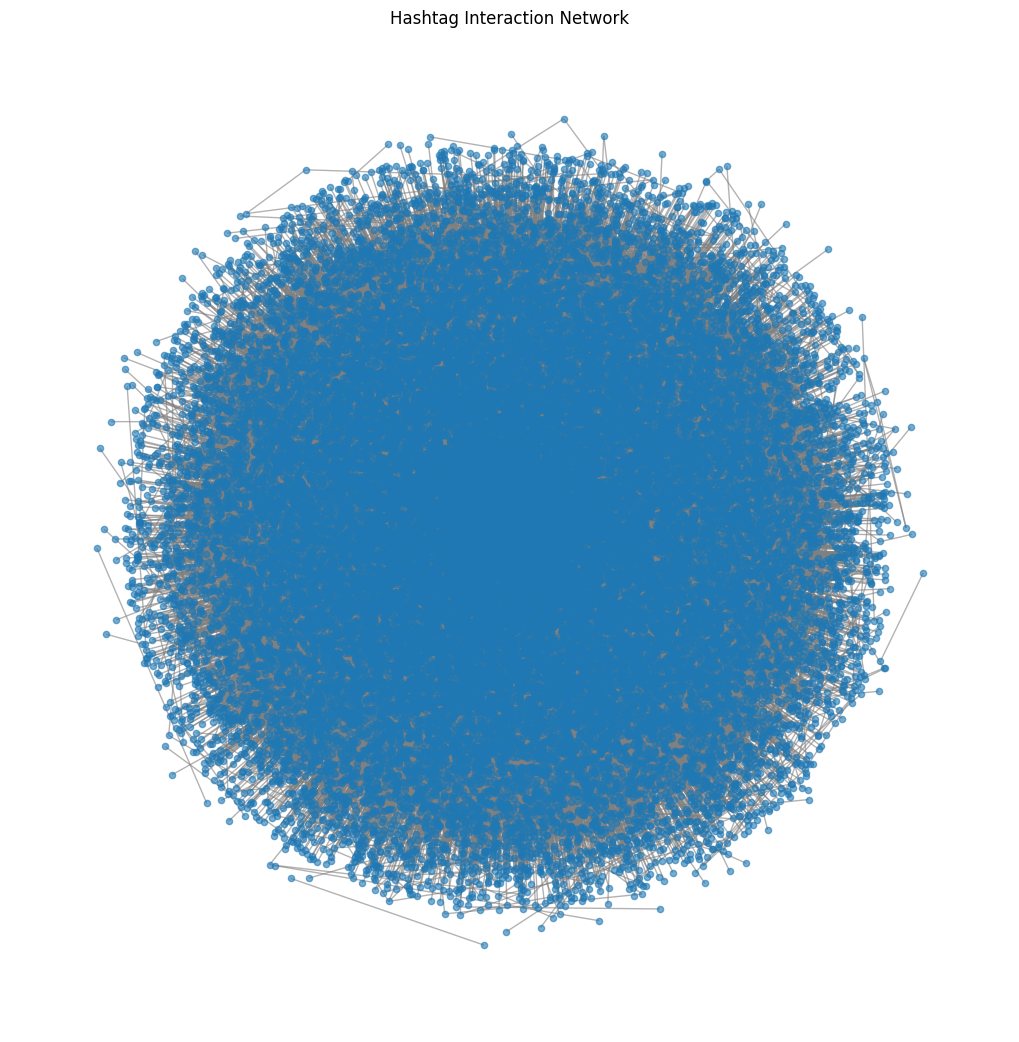

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

pos = nx.spring_layout(G,k=0.15)

nx.draw(G,pos,node_size=20,edge_color="gray",alpha=0.6)

plt.title("Hashtag Interaction Network")

plt.show()

Explode hashtags

In [22]:
hashtags_df = df.explode('hashtag_list')

# convert everything to string
hashtags_df['hashtag_list'] = hashtags_df['hashtag_list'].astype(str)

# clean brackets and quotes
hashtags_df['hashtag_list'] = hashtags_df['hashtag_list'].str.replace("[","", regex=False)
hashtags_df['hashtag_list'] = hashtags_df['hashtag_list'].str.replace("]","", regex=False)
hashtags_df['hashtag_list'] = hashtags_df['hashtag_list'].str.replace("'","", regex=False)
hashtags_df['hashtag_list'] = hashtags_df['hashtag_list'].str.replace(",","", regex=False)

hashtags_df['hashtag_list'] = hashtags_df['hashtag_list'].str.lower().str.strip()

# remove empty
hashtags_df = hashtags_df[hashtags_df['hashtag_list'] != ""]

top_hashtags = hashtags_df['hashtag_list'].value_counts().head(20)

print(top_hashtags)

hashtag_list
covaxin           58657
moderna           44062
covid19           19323
sputnikv          14497
bbmp              14184
vaccine           13295
covidvaccine      12864
pfizer            12218
covishield        11432
sinovac           10377
sinopharm          8301
bengaluru          7021
pfizerbiontech     6548
covid              4775
nan                4650
astrazeneca        3926
vaccinated         3898
vaccines           3391
coronavirus        2777
urban              2768
Name: count, dtype: int64


In [23]:
import networkx as nx
from itertools import combinations

G = nx.Graph()

for hashtags in df['hashtag_list']:
    tags = list(set(hashtags))

    if len(tags) > 1:
        for a, b in combinations(tags, 2):

            if G.has_edge(a, b):
                G[a][b]['weight'] += 1
            else:
                G.add_edge(a, b, weight=1)

In [24]:
import pandas as pd

# NODES
nodes = pd.DataFrame({
    "Id": list(G.nodes()),
    "Label": list(G.nodes())
})

nodes.to_csv("nodes.csv", index=False)


# EDGES
edges = pd.DataFrame(
    [(u, v, d.get("weight", 1)) for u, v, d in G.edges(data=True)],
    columns=["Source", "Target", "Weight"]
)

edges.to_csv("edges.csv", index=False)

print("Files exported!")
print("Nodes:", len(nodes))
print("Edges:", len(edges))

Files exported!
Nodes: 3832
Edges: 69129
